In [1]:
%load_ext autoreload
%autoreload 2
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, viz_h5_structure
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm
from style import set_style

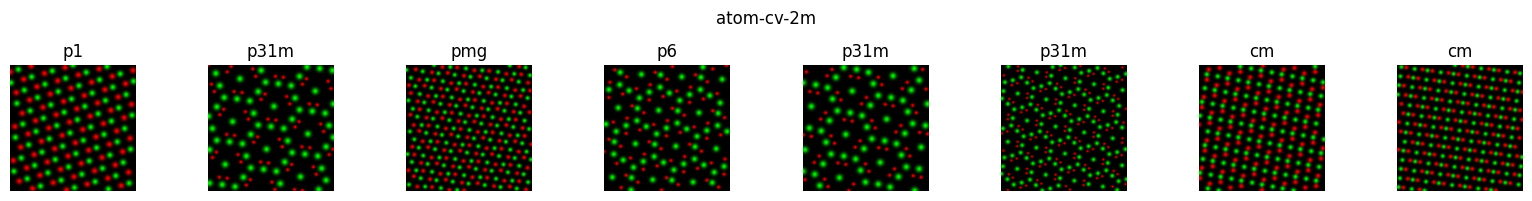

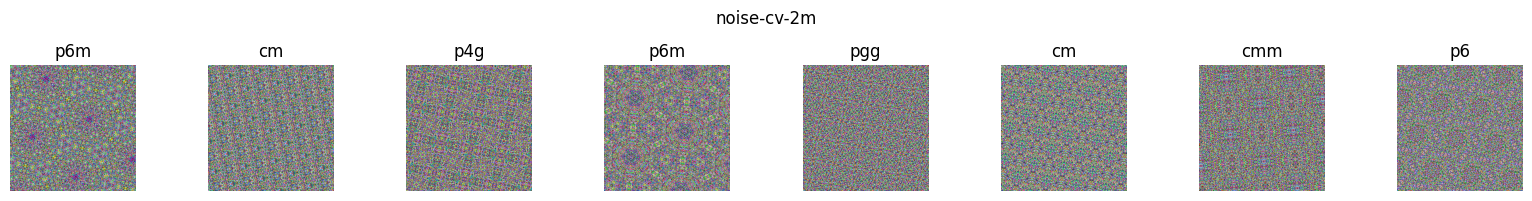

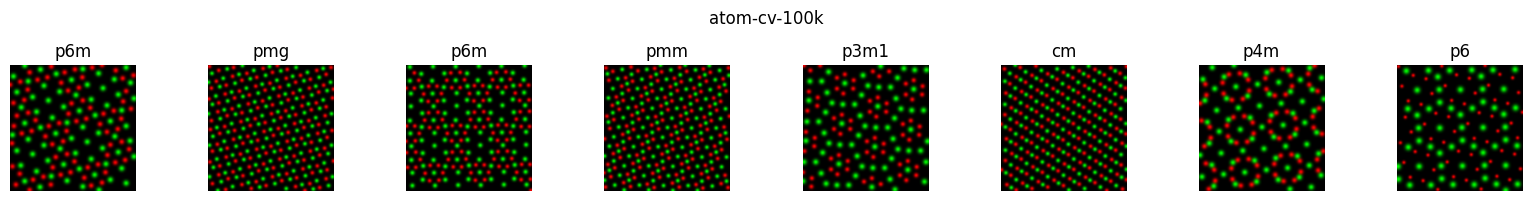

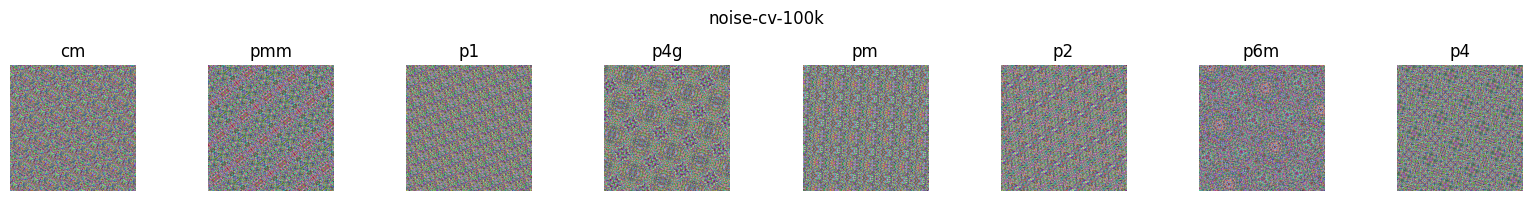

In [2]:
# with h5py.File('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', 'r') as h5:
#     viz_h5_structure(h5)

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=1028, shuffle=True, num_workers=2)
viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

# noise-cv-2m
cv_noise_ds_2m = hdf5_dataset('../../datasets/noise_v4_rot_2m-test.h5', folder='test', transform=transforms.ToTensor())
cv_noise_dl_2m = DataLoader(cv_noise_ds_2m, batch_size=1028, shuffle=True, num_workers=2)
viz_dataloader(cv_noise_dl_2m, label_converter=label_converter, title='noise-cv-2m')

# atom-cv-100k
cv_atom_ds_100k = hdf5_dataset('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='atom', transform=transforms.ToTensor())
cv_atom_dl_100k = DataLoader(cv_atom_ds_100k, batch_size=1028, shuffle=True, num_workers=2)
viz_dataloader(cv_atom_dl_100k, label_converter=label_converter, title='atom-cv-100k')

# noise-cv-100k
cv_noise_ds_100k = hdf5_dataset('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='noise', transform=transforms.ToTensor())
cv_noise_dl_100k = DataLoader(cv_noise_ds_100k, batch_size=1028, shuffle=True, num_workers=2)
viz_dataloader(cv_noise_dl_100k, label_converter=label_converter, title='noise-cv-100k')

### ResNet50

In [24]:
NAME = '01102024-benchmark-resnet50_from_scratch-v4_10m'

model = torch.load('../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt')
device = torch.device('cuda:9')

In [5]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']
for dl, dl_name in zip(dl_list, dl_names):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Benchmark/ResNet50/{NAME}-{dl_name}.npy', cm)

100%|██████████| 1978/1978 [21:12<00:00,  1.55it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 57.931044322184114%


100%|██████████| 1946/1946 [23:56<00:00,  1.35it/s]

...

Accuracy for these batches: 54.374%


100%|██████████| 100/100 [02:00<00:00,  1.20s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 94.82941176470588%


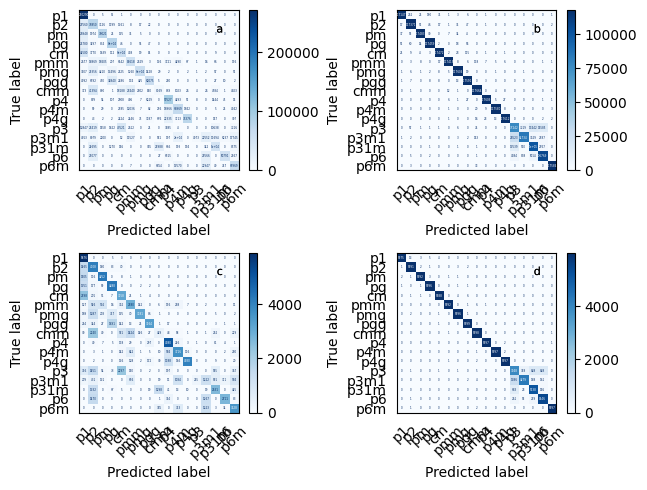

In [25]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, dl_name) in enumerate(zip(axes.flatten(), dl_names)):
    cm = np.load(f'../../saved_results/Benchmark/ResNet50/{NAME}-{dl_name}.npy')
    plot_cm(cm, symmetry_classes, title=None, ax=ax, fig_index=i, cm_style='simple', fig_style='printing', font_size=2)
plt.tight_layout()
plt.show()

### DesNet161

In [26]:
NAME = '01122024-benchmark-DenseNet161-v4_10m'

model = densenet161_(in_channels=3, n_classes=17)
model = torch.load('../../saved_models/01122024-benchmark-DenseNet161-v4_10m/01122024-benchmark-DenseNet161-v4_10m-epoch-20.pt')
device = torch.device('cuda:9')

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [8]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']
for dl, dl_name in zip(dl_list, dl_names):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Benchmark/DenseNet161/{NAME}-{dl_name}.npy', cm)

  0%|          | 0/1978 [00:00<?, ?it/s]

100%|██████████| 1978/1978 [1:08:04<00:00,  2.06s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 55.81861806252857%


...

Accuracy for these batches: 52.081%


100%|██████████| 100/100 [03:27<00:00,  2.07s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 96.36666666666667%


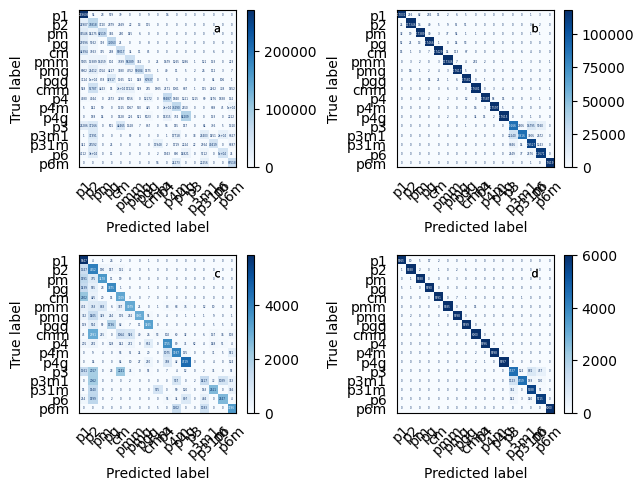

In [27]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, dl_name) in enumerate(zip(axes.flatten(), dl_names)):
    cm = np.load(f'../../saved_results/Benchmark/DenseNet161/{NAME}-{dl_name}.npy')
    plot_cm(cm, symmetry_classes, title=None, ax=ax, fig_index=i, cm_style='simple', fig_style='printing', font_size=2,)
plt.tight_layout()
plt.show()

### FPN

In [ ]:
NAME = '01182024-benchmark-fpn_resnet50-v4_10m'

model = torch.load('../../saved_models/01182024-benchmark-fpn_resnet50-v4_10m/epoch-20.pt')
device = torch.device('cuda:9')

In [30]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']
for dl, dl_name in zip(dl_list, dl_names):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Benchmark/Feature_Pyramid/{NAME}-{dl_name}.npy', cm)

  0%|          | 0/1978 [00:00<?, ?it/s]

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
100%|██████████| 1978/1978 [35:47<00:00,  1.09s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 59.088849520254215%


...

Accuracy for these batches: 55.639%


  0%|          | 0/100 [00:00<?, ?it/s]/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
100%|██████████| 100/100 [01:46<00:00,  1.06s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 96.25392156862745%


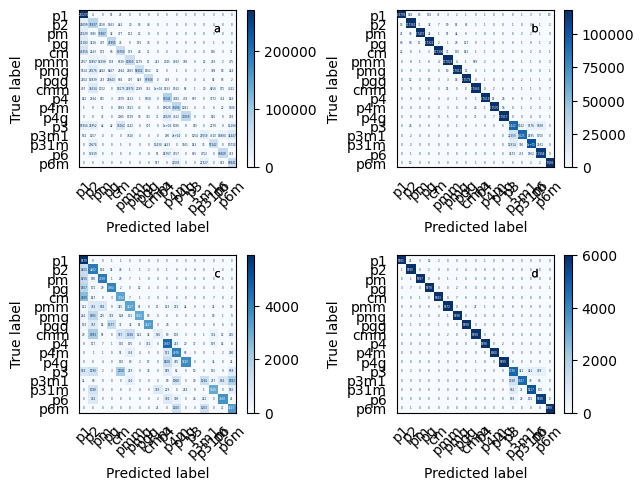

In [31]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, dl_name) in enumerate(zip(axes.flatten(), dl_names)):
    cm = np.load(f'../../saved_results/Benchmark/Feature_Pyramid/{NAME}-{dl_name}.npy')
    plot_cm(cm, symmetry_classes, title=None, ax=ax, fig_index=i, cm_style='simple', fig_style='printing', font_size=2)
plt.tight_layout()
plt.show()

### XCiT

In [6]:
NAME = '01102024-benchmark-XCiT-v4_10m'
device = torch.device('cuda:9')
model = torch.load('../../saved_models/01102024-benchmark-XCiT-v4_10m/01102024-benchmark-XCiT-v4_10m-epoch-20.pt').module

In [8]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']
for dl, dl_name in zip(dl_list, dl_names):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Benchmark/XCiT/{NAME}-{dl_name}.npy', cm)

  0%|          | 0/1978 [00:00<?, ?it/s]

100%|██████████| 1978/1978 [2:22:48<00:00,  4.33s/it]  

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 56.17815067013867%


...

Accuracy for these batches: 52.491%


100%|██████████| 100/100 [07:16<00:00,  4.36s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 98.28039215686275%


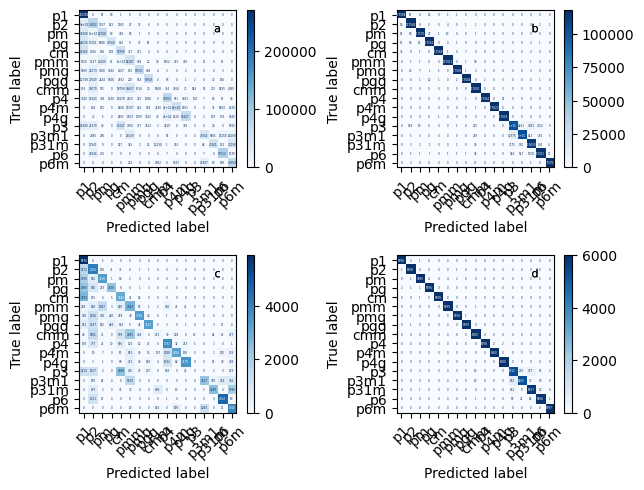

In [9]:
dl_list = [cv_atom_dl_2m, cv_noise_dl_2m, cv_atom_dl_100k, cv_noise_dl_100k]
dl_names = ['cv_atom_2m', 'cv_noise_2m', 'cv_atom_100k', 'cv_noise_100k']

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, dl_name) in enumerate(zip(axes.flatten(), dl_names)):
    cm = np.load(f'../../saved_results/Benchmark/XCiT/{NAME}-{dl_name}.npy')
    plot_cm(cm, symmetry_classes, title=None, ax=ax, fig_index=i, cm_style='simple', fig_style='printing', font_size=2)
plt.tight_layout()
plt.show()

### visualize confusions in compact layout

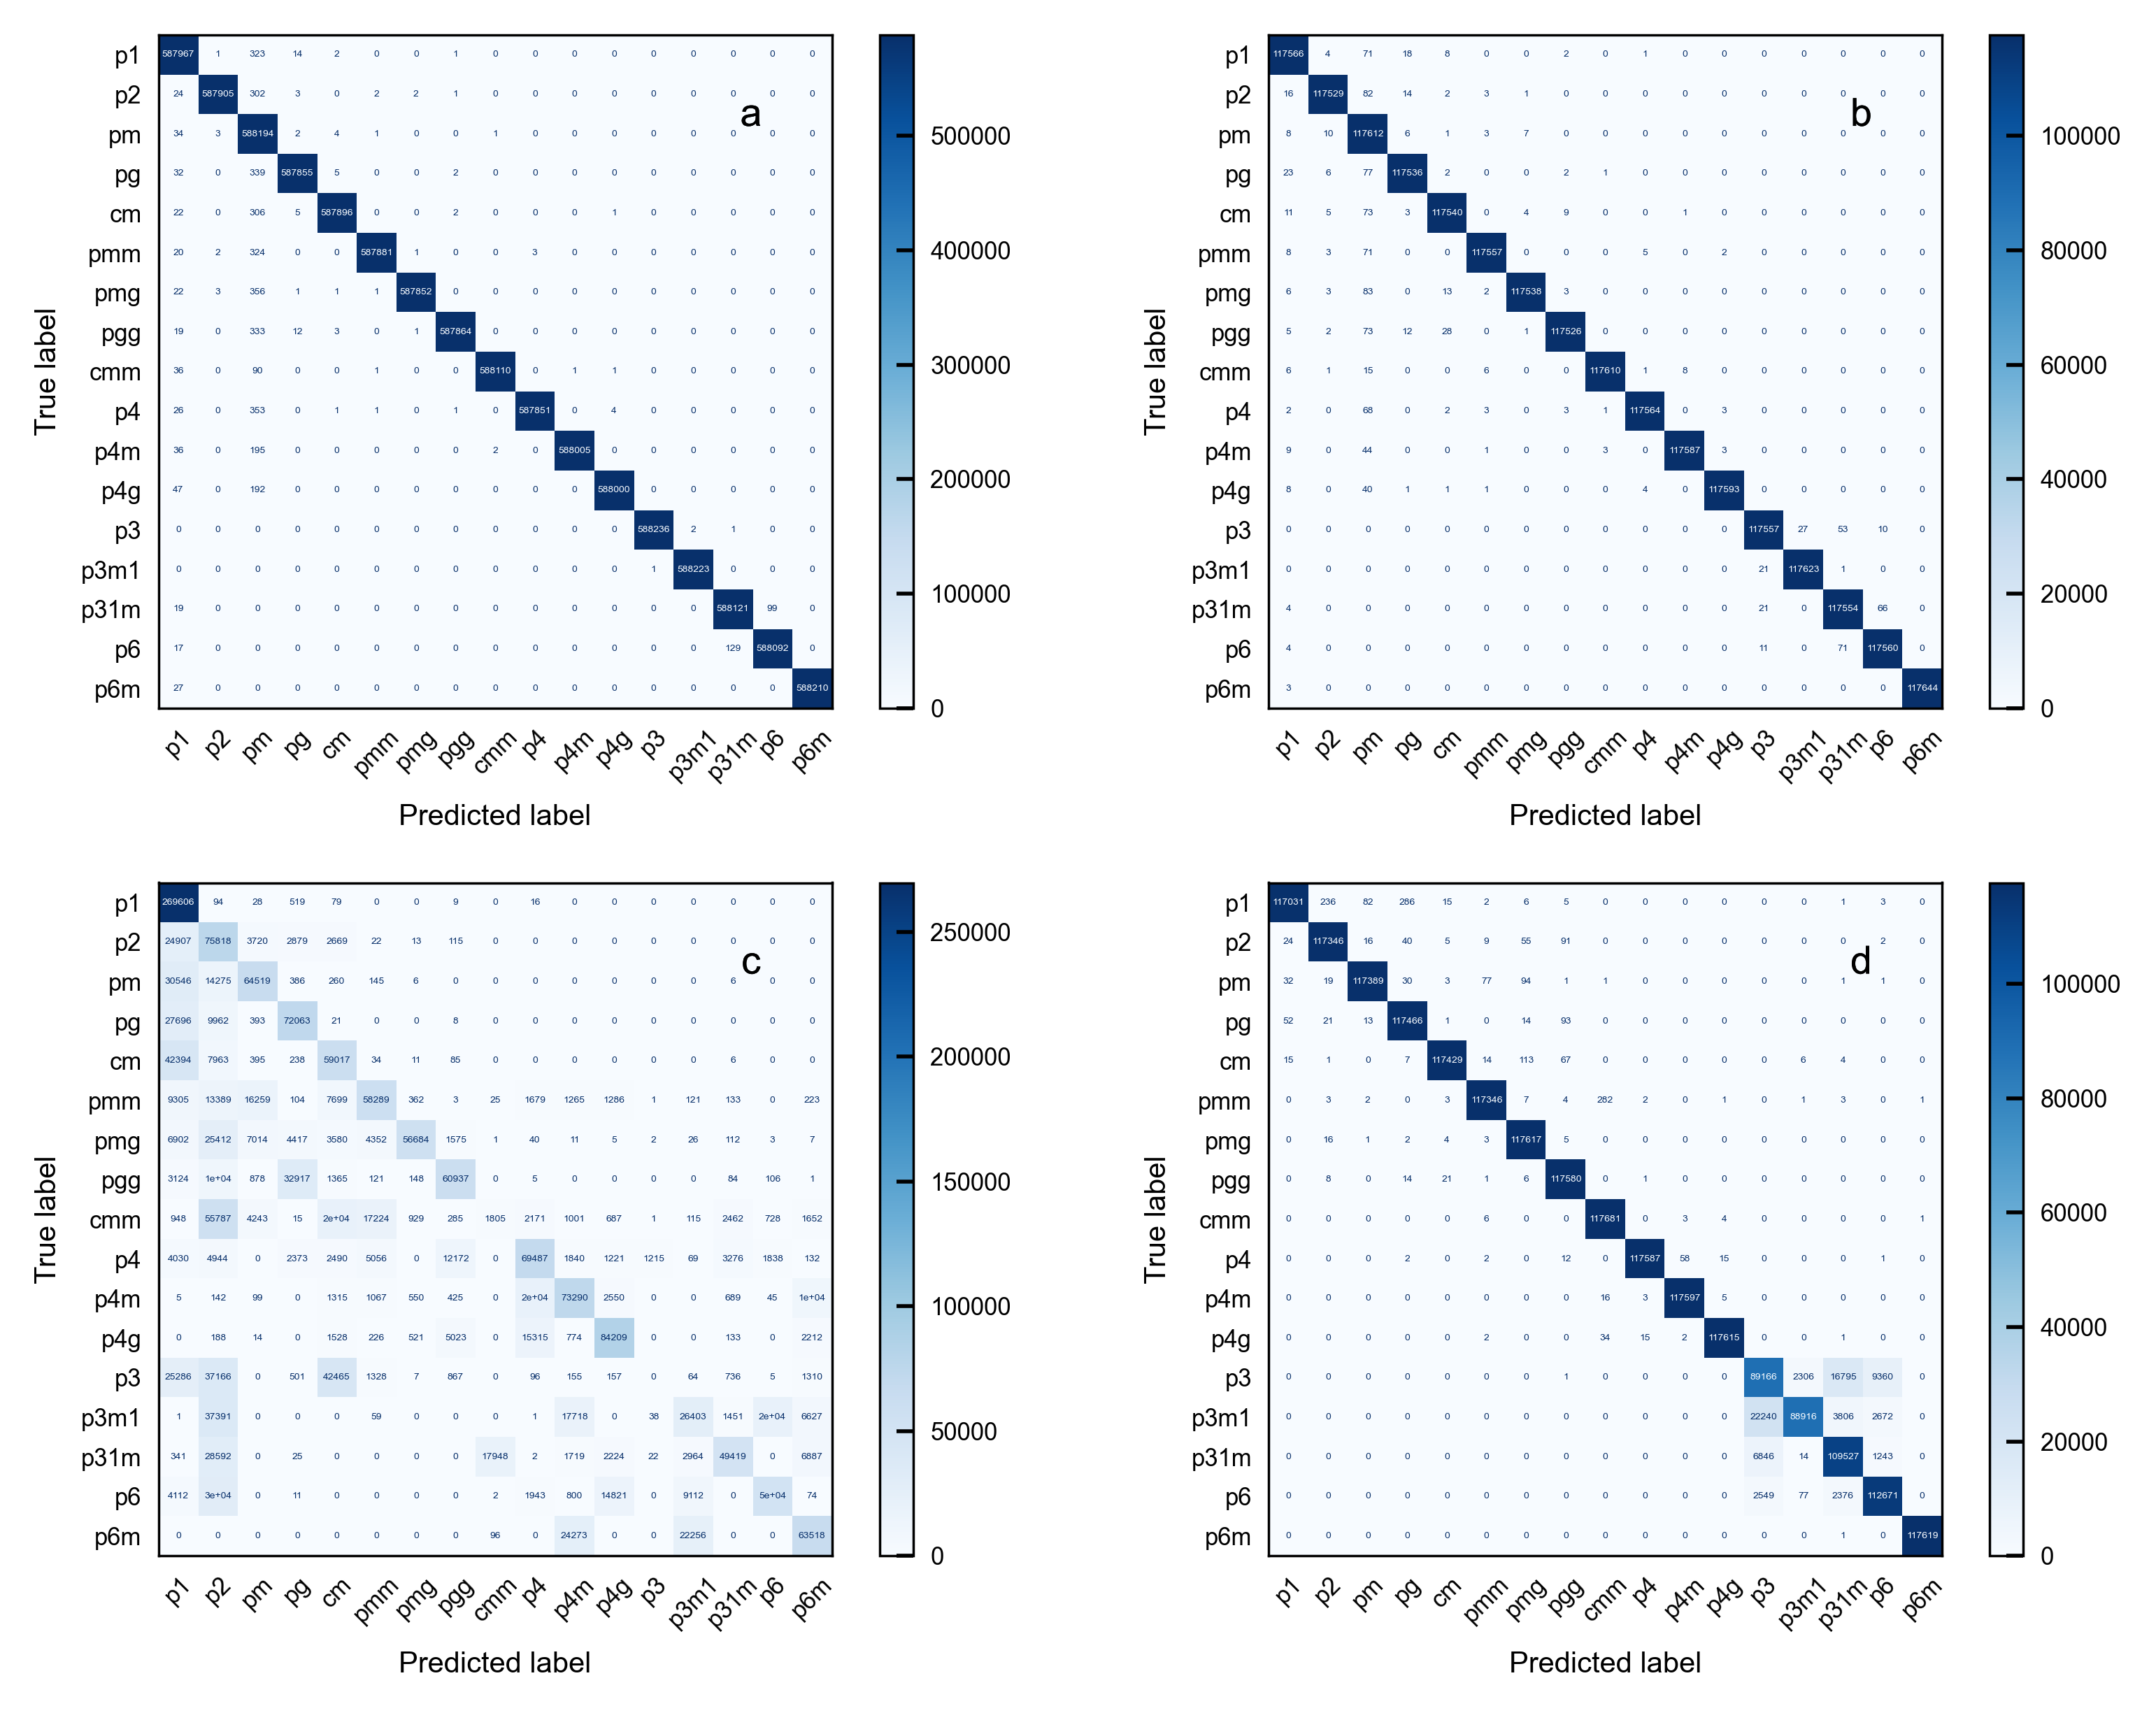

In [6]:
files = glob.glob(f'../../../saved_results/Benchmark/DenseNet161/*')
keywords = ['train', 'valid', 'cv_atom_cm', 'cv_noise_cm']

show_cm(files, keywords, summary=True, title_head=None, cm_style='simple', fig_style='printing', font_size=2,
        file_path='../../../figures/Benchmark/DenseNet161/Summary_cm-DenseNet161')

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font '] = 'Helvetica Medium Condensed'  # or any other available sans-serif font

In [1]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

order = ['train', 'valid', 'cv_atom_cm', 'cv_noise_cm']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

files = glob.glob(f'../../../saved_results/Benchmark/DenseNet161/*')
sorted_files = sorted(files, key=sort_key)
for file, group in zip(sorted_files, order):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title='DenseNet161 - '+group, cm_style='simple', fig_style='printing', font_size=4)

NameError: name 'glob' is not defined

### visualize confusions in compact layout

In [9]:
from matplotlib.font_manager import findSystemFonts
findSystemFonts()

['/usr/share/fonts/truetype/lato/Lato-BlackItalic.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Light.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerif-BoldItalic.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Bold.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Oblique.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerifCondensed-Italic.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Semibold.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Medium.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Thin.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerifCondensed-Bold.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansMono-BoldOblique.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed.ttf',
 '/usr/share/fonts/truetype/lato/Lato-Hairline.ttf',
 '/usr/share/fonts/truetype/lato/Lato-LightItalic.ttf',
 '/usr/share/fonts/truetype/lato/Lato-MediumItalic.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf',
 '/usr/share/fonts/true

In [10]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

Summary_cm-01122024-benchmark


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

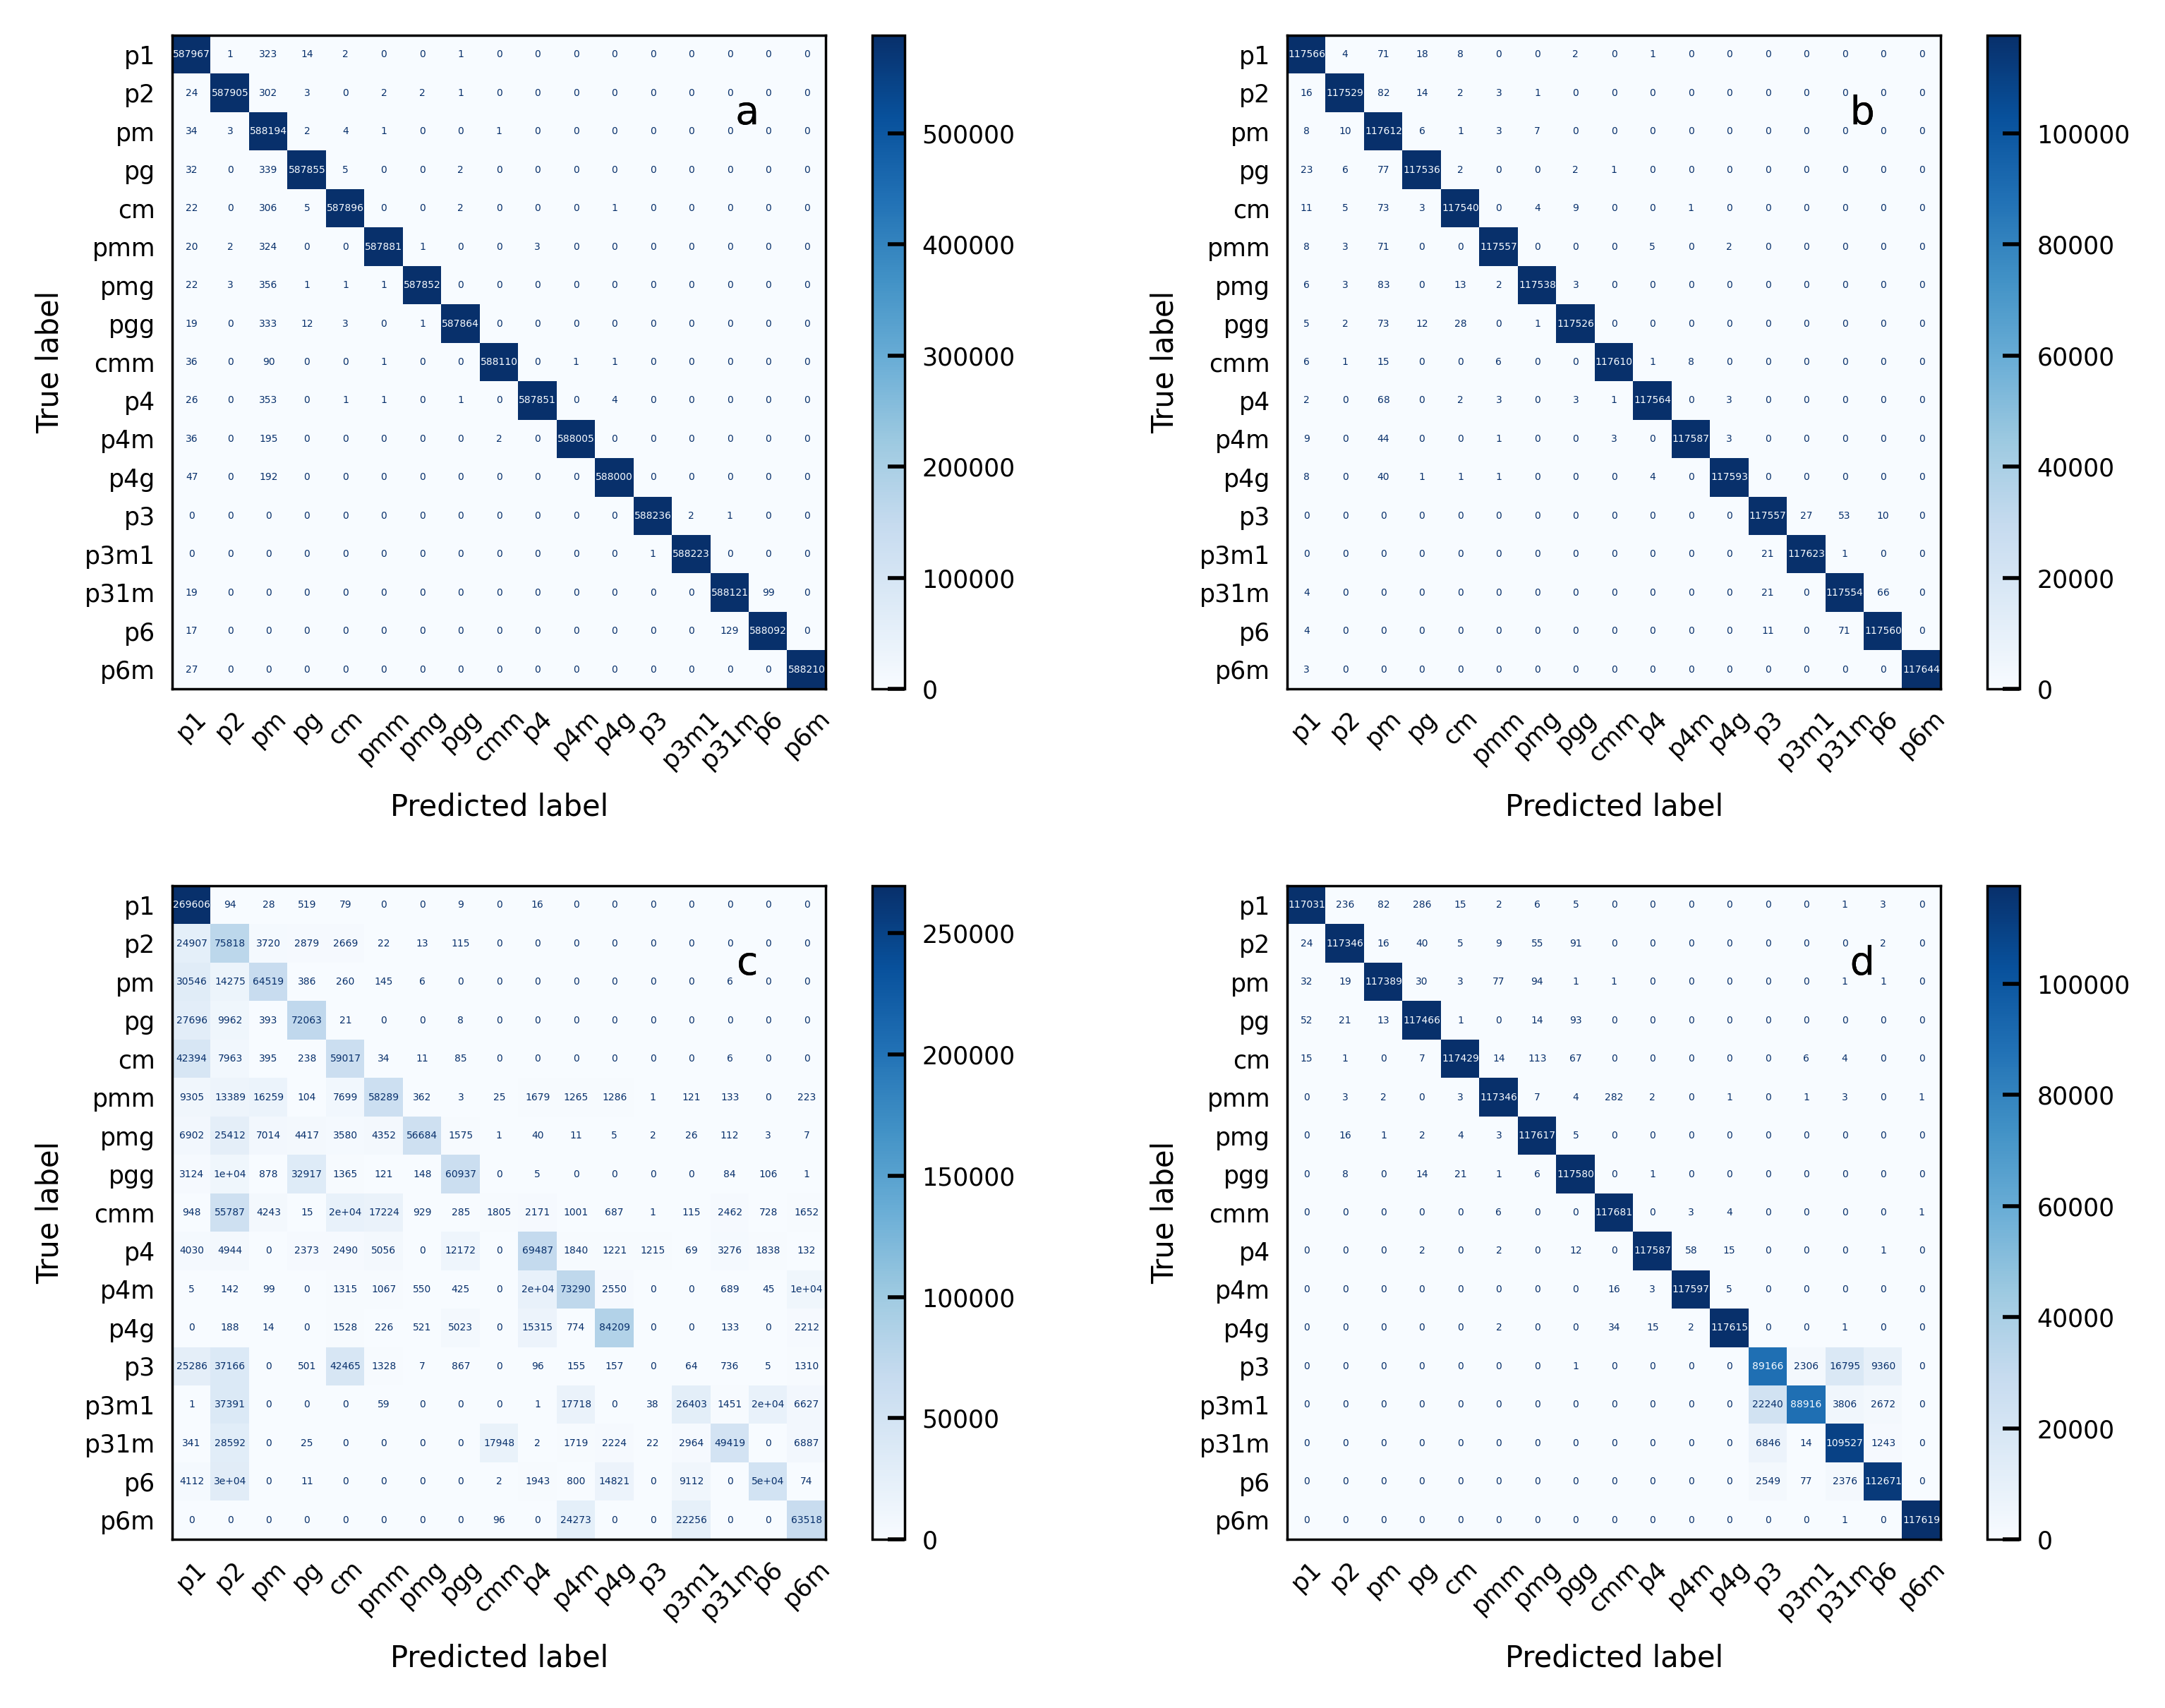

In [11]:
# print(sorted_files)
NAME = 'Summary_cm-' + '-'.join(os.path.basename(sorted_files[0]).split('-')[:2])
print(NAME)

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, file) in enumerate(zip(axes.flatten(), sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=2)
plt.tight_layout()
plt.savefig(f'../../../figures/Benchmark/DenseNet161/{NAME}.png')
plt.savefig(f'../../../figures/Benchmark/DenseNet161/{NAME}.svg')
plt.show()